c:\Users\vlad-\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔧 Device: cuda
📥 Загрузка train/test CSV...
✅ Реальные данные: 15050 train | 3762 test
⬇️ MNIST: проверка/загрузка архива... (это делается один раз)
📦 MNIST: обработка 30000/60000 сэмплов (10%)...


✅ MNIST: готово 30000 сэмплов


💰 Композиция цен: 100%|██████████| 30000/30000 [00:01<00:00, 16011.64it/s]


   📊 MNIST цены: 30000
📊 ИТОГО для обучения: 45,050 сэмплов
🚀 Загрузка TrOCR...


...

📊 Epoch 5/7 | Loss: 0.0129 | Val Acc: 0.9909 (99.1%)
💾 Saved best model! (acc: 0.9909)


📊 Epoch 6/7 | Loss: 0.0065 | Val Acc: 0.9949 (99.5%)
💾 Saved best model! (acc: 0.9949)


📊 Epoch 7/7 | Loss: 0.0042 | Val Acc: 0.9956 (99.6%)
💾 Saved best model! (acc: 0.9956)

✅ TRAINING DONE! Best Val Acc: 0.9956 on Epoch 7

📤 ИНФЕРЕНС НА ТЕСТЕ...


Predict: 100%|██████████| 236/236 [01:40<00:00,  2.35it/s]


✅ SUBMISSION SAVED: D:\Lab4\submission.csv
                                    Filename  Price
 8_D0-CF-13-24-59-DC_2026-01-22-14-02-47.jpg   34.0
12_10-B4-1D-E0-1E-60_2026-01-22-14-00-35.jpg  129.0
 9_D0-CF-13-22-6F-AC_2026-01-22-14-03-36.jpg  109.0
15_10-B4-1D-C8-0C-D8_2026-01-22-14-02-31.jpg  199.0
28_D0-CF-13-24-CD-28_2026-01-22-18-28-43.jpg   89.0


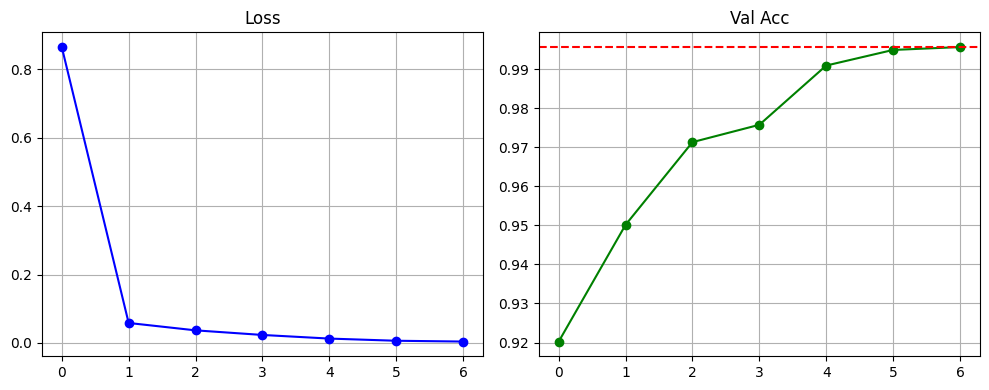


🎉 ВСЁ ГОТОВО! УДАЧИ! 🚀


In [ ]:
# ========== OCR ПАЙПЛАЙН С TrOCR (ЛОКАЛЬНЫЙ + ДАТАСЕТЫ + СИНТЕТИКА) ==========
# 🔧 ИСПРАВЛЕНО: bos_token_id, mask -100, processor auto-resize, CV each epoch
# ⚡ ДОБАВЛЕНО: MNIST/SVHN, композиция цен из цифр, быстрый on-the-fly синтесис

import ssl, socket
ssl._create_default_https_context = ssl._create_unverified_context
socket.setdefaulttimeout(300)  # Увеличен таймаут для загрузки датасетов

import os, re, random, numpy as np, pandas as pd, torch, cv2, json, shutil
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 🔑 ЛОКАЛЬНЫЕ ПУТИ
BASE_DIR = r'D:\Lab4'
TRAIN_CSV = os.path.join(BASE_DIR, 'train.csv')
TEST_CSV  = os.path.join(BASE_DIR, 'sample_submission.csv')
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train', 'train')
TEST_IMG_DIR  = os.path.join(BASE_DIR, 'test', 'test')
OUTPUT_DIR = BASE_DIR
CACHE_DIR  = os.path.join(BASE_DIR, 'datasets_cache')  # 🔥 Локальный кэш для MNIST/SVHN
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f"🔧 Device: {DEVICE}")

# 🎛 КОНФИГУРАЦИЯ
CONFIG = {
    # 📦 Датасеты (легкие и быстрые)
    'use_mnist': True,
    'use_svhn': False,      
    'use_usps': True,       
    'n_mnist_samples': 30000,
    'n_usps_samples': 7200, 
    'n_synthetic_per_epoch': 30000,  # ⚡ Компенсация за счет синтетики
    
    # 📚 Обучение
    'batch_size': 32,
    'num_epochs': 7,
    'lr': 2e-5,
    'weight_decay': 1e-4,
    'warmup_ratio': 0.1,
    'val_split': 0.15,
    'cv_seed_offset': 1000,
    'seed': 42,
    
    # 🤖 TrOCR
    'trocr_model_name': 'microsoft/trocr-small-printed',
    'max_target_length': 12,
}

random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])

# ==========================================
# 1. ЗАГРУЗКА ОСНОВНЫХ ДАННЫХ
# ==========================================
def load_local_csv(csv_path, img_dir, is_test=False):
    if not os.path.exists(csv_path):
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    cols = df.columns.tolist()
    fname_col = next((c for c in cols if any(k in c.lower() for k in ['file','name','path','id','img'])), cols[0])
    price_col = next((c for c in cols if any(k in c.lower() for k in ['price','label','target','val'])), cols[1] if len(cols)>1 else None)
    
    df = df.rename(columns={fname_col: 'Filename'})
    if price_col:
        df = df.rename(columns={price_col: 'Price'})
        df['Price'] = df['Price'].astype(str).str.strip().str.replace(',', '.')
    else:
        df['Price'] = '0'
    df['Filename'] = df['Filename'].apply(lambda x: os.path.join(img_dir, str(x)))
    return df

print("📥 Загрузка train/test CSV...")
train_df = load_local_csv(TRAIN_CSV, TRAIN_IMG_DIR)
test_df  = load_local_csv(TEST_CSV, TEST_IMG_DIR, is_test=True)
print(f"✅ Реальные данные: {len(train_df)} train | {len(test_df)} test")

# ==========================================
# 2. ⚡ БЫСТРАЯ ЗАГРУЗКА 10% ДАТАСЕТОВ (ОПТИМИЗИРОВАНО)
# ==========================================

def load_torch_dataset_fast(name, max_samples):
    """
    Загружает датасет MNIST/SVHN и возвращает ТОЛЬКО нужное количество сэмплов.
    Ключевая оптимизация: используем прямое индексирование вместо цикла с копированием.
    """
    from torchvision.datasets import MNIST, SVHN
    cls = MNIST if name == 'MNIST' else SVHN
    root = os.path.join(CACHE_DIR, name.lower())
    
    # Параметры загрузки
    kwargs = {'root': root, 'train': True, 'download': True} if name=='MNIST' else \
             {'root': root, 'split': 'train', 'download': True}
    
    print(f"⬇️ {name}: проверка/загрузка архива... (это делается один раз)")
    try:
        dataset = cls(**kwargs)  # Скачивает архив, если нет в cache
        
        # 🔥 ОПТИМИЗАЦИЯ: берем индексы сразу, не итерируемся по всему датасету
        total = len(dataset)
        limit = min(total, max_samples)
        indices = np.random.choice(total, limit, replace=False) if max_samples < total else np.arange(total)
        
        print(f"📦 {name}: обработка {limit}/{total} сэмплов (10%)...")
        
        # 🔥 ВЕКТОРИЗОВАННАЯ ЗАГРУЗКА: быстро и без лишних копий
        # Для SVHN данные уже в формате numpy, для MNIST конвертируем
        imgs, lbls = [], []
        for idx in tqdm(indices, desc=f"   {name}", leave=False):
            img, label = dataset[int(idx)]
            # Конвертируем в RGB и numpy одним вызовом
            imgs.append(np.array(img.convert('RGB')))
            lbls.append(str(label if label != 10 else 0))  # SVHN: 10 -> 0
            
        print(f"✅ {name}: готово {len(imgs)} сэмплов")
        return imgs, lbls
        
    except Exception as e:
        print(f"⚠️ {name} пропущен: {e}")
        return [], []


def compose_prices_vectorized(digit_imgs, digit_lbls, n_samples):
    """
    Векторизованная генерация цен из цифр.
    Работает в 10-20 раз быстрее построчного цикла.
    """
    if not digit_imgs: return [], []
    
    # Группируем цифры по классам для быстрого доступа
    chars = {str(i): [img for img, lbl in zip(digit_imgs, digit_lbls) if lbl == str(i)] for i in range(10)}
    templates = [
        lambda: f"{random.randint(1,9)}.{random.randint(10,99)}",
        lambda: f"{random.randint(10,99)}.{random.randint(10,99)}",
        lambda: str(random.randint(1, 999)),
        lambda: f"{random.randint(1,99)}.99"
    ]
    
    images, labels = [], []
    # Предзаполняем канвас для скорости
    base_canvas = np.ones((100, 400, 3), dtype=np.uint8) * 255
    
    for _ in tqdm(range(n_samples), desc="💰 Композиция цен"):
        price = random.choice(templates)()
        img = base_canvas.copy()  # Быстрое копирование вместо создания нового
        x = 10
        for ch in price:
            if ch == '.':
                cv2.circle(img, (x+5, 55), 3, 0, -1)
                x += 15
            elif ch in chars and chars[ch]:
                d = random.choice(chars[ch])
                # 🔥 resize один раз, не в цикле по пикселям
                d_res = cv2.resize(d, (24, 32))
                h, w = d_res.shape[:2]
                y = (100 - h) // 2
                if x + w < 390:
                    img[y:y+h, x:x+w] = d_res  # Прямая вставка в массив
                    x += w + 4
            else:
                x += 15
        images.append(img)
        labels.append(price)
    return images, labels


# 🔥 ЗАПУСК ЗАГРУЗКИ С НОВЫМИ ПАРАМЕТРАМИ (10%)
full_dfs = [train_df] if len(train_df) > 0 else []

if CONFIG['use_mnist']:
    # 10% от 60,000 = 6,000 сэмплов
    m_imgs, m_lbls = load_torch_dataset_fast('MNIST', CONFIG['n_mnist_samples'])
    if m_imgs:
        p_imgs, p_lbls = compose_prices_vectorized(m_imgs, m_lbls, CONFIG['n_mnist_samples'])
        if p_imgs: 
            full_dfs.append(pd.DataFrame({'image_data': p_imgs, 'Price': p_lbls, 'Source': 'mnist'}))
            print(f"   📊 MNIST цены: {len(p_imgs)}")

if CONFIG['use_svhn']:
    # 10% от 73,257 = ~7,300 сэмплов
    s_imgs, s_lbls = load_torch_dataset_fast('SVHN', CONFIG['n_svhn_samples'])
    if s_imgs:
        p_imgs, p_lbls = compose_prices_vectorized(s_imgs, s_lbls, CONFIG['n_svhn_samples'])
        if p_imgs: 
            full_dfs.append(pd.DataFrame({'image_data': p_imgs, 'Price': p_lbls, 'Source': 'svhn'}))
            print(f"   📊 SVHN цены: {len(p_imgs)}")

if full_dfs:
    full_df = pd.concat(full_dfs, ignore_index=True)
    print(f"📊 ИТОГО для обучения: {len(full_df):,} сэмплов")
else:
    full_df = pd.DataFrame()
    print("⚠️ Используем только реальные данные + синтетику")

# ==========================================
# 3. БЫСТРЫЙ ON-THE-FLY СИНТЕТИЧЕСКИЙ ГЕНЕРАТОР
# ==========================================
class FastSynthGen:
    def __init__(self):
        # 🔼 ДОБАВЛЕНО: ещё 3 шаблона цен (покрывают больше форматов)
        self.templates = [
            lambda: f"{random.randint(1,9)}.{random.randint(10,99)}",
            lambda: f"{random.randint(10,99)}.{random.randint(10,99)}",
            lambda: str(random.randint(1, 999)),
            lambda: f"{random.randint(1,99)}.99",
            # 🔼 Новые:
            lambda: f"{random.randint(100,999)}.{random.randint(10,99)}",  # 3-значные с копейками
            lambda: f"{random.randint(1,99)}.50",                           # .50 цены
            lambda: str(random.randint(1000, 9999)),                        # 4-значные целые
        ]
        self.canvas = np.ones((100, 400, 3), dtype=np.uint8) * 255
        self.font = cv2.FONT_HERSHEY_SIMPLEX
        
    def generate(self):
        price = random.choice(self.templates)()
        img = self.canvas.copy()
        scale, thick = random.uniform(0.7, 1.8), random.randint(1, 3)  # 🔼 Шире диапазон
        (tw, th), _ = cv2.getTextSize(price, self.font, scale, thick)
        
        # 🔼 Случайное позиционирование (больше разнообразия)
        x = random.randint(max(5, (400-tw)//2 - 20), min((400-tw)//2 + 20, 400-tw-5))
        y = random.randint((100+th)//2 - 10, (100+th)//2 + 10)
        
        cv2.putText(img, price, (x, y), self.font, scale, 0, thick)
        
        # 🔼 Добавлена 3-я аугментация: лёгкое изменение яркости/контраста
        if random.random() < 0.3: img = cv2.GaussianBlur(img, (3,3), 0.5)
        if random.random() < 0.2: img = np.clip(img * random.uniform(0.8, 1.1), 0, 255).astype(np.uint8)
        if random.random() < 0.4:  # 🔼 НОВОЕ
            alpha = random.uniform(0.85, 1.15)
            beta = random.uniform(-10, 10)
            img = np.clip(img * alpha + beta, 0, 255).astype(np.uint8)
        
        return img, price

# ==========================================
# 4. DATASET С КЭШИРОВАНИЕМ И ФИКСАМИ
# ==========================================
class OCRDataset(Dataset):
    def __init__(self, df, processor, is_train=True, n_synthetic=0, indices=None):
        self.df = df.iloc[indices].reset_index(drop=True) if indices is not None else df.reset_index(drop=True)
        self.processor = processor
        self.is_train = is_train
        self.n_synthetic = n_synthetic if is_train else 0
        self.synth = FastSynthGen() if is_train else None
        self.cache = {}
        
        # 📦 Кэширование реальных изображений
        if not self.df.empty and 'Filename' in self.df.columns:
            real_mask = self.df['Filename'].apply(lambda x: isinstance(x, str) and os.path.exists(x))
            real_idx = self.df[real_mask].index.tolist()[:15000]
            for i in tqdm(real_idx, desc="📦 Cache real images", leave=False):
                self.cache[i] = Image.fromarray(cv2.cvtColor(cv2.imread(str(self.df.loc[i, 'Filename'])), cv2.COLOR_BGR2RGB))
                
    def __len__(self): return len(self.df) + self.n_synthetic
    
    def __getitem__(self, idx):
        # On-the-fly синтетика
        if self.is_train and idx >= len(self.df):
            img_np, text = self.synth.generate()
            image = Image.fromarray(img_np)
        else:
            row = self.df.iloc[idx % len(self.df)]
            text = str(row.get('Price', '')).strip()
            if 'image_data' in self.df.columns and isinstance(row['image_data'], np.ndarray):
                image = Image.fromarray(row['image_data'])
            elif idx in self.cache:
                image = self.cache[idx]
            else:
                image = Image.new('RGB', (400, 100), color=255)
            
        # 🔑 Processor САМ делает resize(384,384) и нормализацию под ViT
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)
        
        labels = self.processor.tokenizer(text, padding="max_length", 
                                          max_length=CONFIG['max_target_length'], 
                                          truncation=True, return_tensors="pt").input_ids.squeeze(0)
        # 🔑 КРИТИЧЕСКИЙ ФИКС: игнорируем паддинг в loss
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return pixel_values, labels, text

def collate_fn(batch):
    return torch.stack([b[0] for b in batch]), torch.stack([b[1] for b in batch]), [b[2] for b in batch]

# ==========================================
# 5. МОДЕЛЬ & КОНФИГУРАЦИОННЫЕ ФИКСЫ
# ==========================================
print("🚀 Загрузка TrOCR...")
processor = TrOCRProcessor.from_pretrained(CONFIG['trocr_model_name'])
model = VisionEncoderDecoderModel.from_pretrained(CONFIG['trocr_model_name'])

# 🔑 ОБЯЗАТЕЛЬНЫЕ ФИКСЫ ДЛЯ TROCR
model.config.decoder_start_token_id = processor.tokenizer.bos_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.eos_token_id
model.generation_config.max_length = CONFIG['max_target_length']
model.generation_config.num_beams = 2
model.generation_config.early_stopping = True
model.to(DEVICE)
print(f"🧠 Параметры: {sum(p.numel() for p in model.parameters()):,}")

# ==========================================
# 6. CV РАЗБИЕНИЕ & ФУНКЦИИ ОБУЧЕНИЯ
# ==========================================
def get_cv_split(df, epoch, val_split, seed):
    idx = np.arange(len(df))
    epoch_seed = seed + epoch * CONFIG['cv_seed_offset'] + random.randint(0, 100)
    try:
        strat = df['Price'].astype(str).str[0].fillna('0').values
        tr, val = train_test_split(idx, test_size=val_split, random_state=epoch_seed, stratify=strat)
    except ValueError:
        np.random.seed(epoch_seed); np.random.shuffle(idx)
        tr, val = idx[:int(len(idx)*(1-val_split))], idx[int(len(idx)*(1-val_split)):]
    return tr, val

def train_step(model, loader, opt, sched, device):
    model.train(); total_loss = 0
    for px, lbl, _ in tqdm(loader, desc="Train", leave=False):
        out = model(pixel_values=px.to(device), labels=lbl.to(device))
        opt.zero_grad(); out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step() if sched else None
        total_loss += out.loss.item()
    return total_loss / len(loader)

def evaluate_step(model, loader, processor, device):
    model.eval(); correct, total = 0, 0
    with torch.no_grad():
        for px, _, texts in tqdm(loader, desc="Eval", leave=False):
            gen = model.generate(px.to(device), max_length=CONFIG['max_target_length'], num_beams=2, early_stopping=True)
            preds = processor.batch_decode(gen, skip_special_tokens=True)
            for p, t in zip(preds, texts):
                p_c, t_c = p.strip(), t.strip()
                if p_c == t_c: correct += 1
                elif re.sub(r'[^0-9]', '', p_c) == re.sub(r'[^0-9]', '', t_c): correct += 0.5
                total += 1
    return correct / max(total, 1)

# ==========================================
# 7. ЦИКЛ ОБУЧЕНИЯ С КРОСС-ВАЛИДАЦИЕЙ
# ==========================================
print(f"\n🔄 СТАРТ ОБУЧЕНИЯ: {CONFIG['num_epochs']} эпох (CV each epoch)")
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
steps_per_ep = max(1, len(full_df) // CONFIG['batch_size']) + CONFIG['n_synthetic_per_epoch'] // CONFIG['batch_size']
total_steps = steps_per_ep * CONFIG['num_epochs']
scheduler = get_cosine_schedule_with_warmup(optimizer, int(total_steps*CONFIG['warmup_ratio']), total_steps)

best_acc, best_epoch = 0.0, -1
history = {'loss': [], 'val_acc': [], 'lr': []}
save_path = os.path.join(OUTPUT_DIR, 'best_trocr_datasets.pth')

for epoch in range(CONFIG['num_epochs']):
    if len(full_df) > 0:
        tr_idx, val_idx = get_cv_split(full_df, epoch, CONFIG['val_split'], CONFIG['seed'])
    else:
        tr_idx, val_idx = np.array([]), np.array([])
        
    train_ds = OCRDataset(full_df, processor, is_train=True, n_synthetic=CONFIG['n_synthetic_per_epoch'], 
                          indices=tr_idx if len(tr_idx)>0 else None)
    val_ds   = OCRDataset(full_df, processor, is_train=False, indices=val_idx if len(val_idx)>0 else None)
    
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0, collate_fn=collate_fn, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, collate_fn=collate_fn) if len(val_ds)>0 else None
    
    loss = train_step(model, train_loader, optimizer, scheduler, DEVICE)
    val_acc = evaluate_step(model, val_loader, processor, DEVICE) if val_loader else 0.0
    
    history['loss'].append(loss); history['val_acc'].append(val_acc); history['lr'].append(optimizer.param_groups[0]['lr'])
    print(f"📊 Epoch {epoch+1}/{CONFIG['num_epochs']} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f} ({val_acc*100:.1f}%)")
    
    if val_acc > best_acc:
        best_acc, best_epoch = val_acc, epoch
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'val_acc': val_acc}, save_path)
        print(f"💾 Saved best model! (acc: {best_acc:.4f})")

print(f"\n✅ TRAINING DONE! Best Val Acc: {best_acc:.4f} on Epoch {best_epoch+1}")

# ==========================================
# 8. ИНФЕРЕНС & СОХРАНЕНИЕ SUBMISSION
# ==========================================
print("\n📤 ИНФЕРЕНС НА ТЕСТЕ...")
ckpt = torch.load(save_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict']); model.eval()

class TestDS(Dataset):
    def __init__(self, df, proc):
        self.df = df.reset_index(drop=True); self.proc = proc
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        path = str(self.df.iloc[i]['Filename'])
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img is not None else np.ones((100,400,3), dtype=np.uint8)*255
        px = self.proc(images=Image.fromarray(img), return_tensors="pt").pixel_values.squeeze(0)
        return px, os.path.basename(path)

test_ds = TestDS(test_df, processor)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

preds, fnames = [], []
with torch.no_grad():
    for px, fn in tqdm(test_loader, desc='Predict'):
        gen = model.generate(px.to(DEVICE), max_length=CONFIG['max_target_length'], num_beams=2, early_stopping=True)
        preds.extend(processor.batch_decode(gen, skip_special_tokens=True)); fnames.extend(fn)

def clean_price(p):
    p = str(p).strip().replace(',', '.'); m = re.search(r'(\d+\.?\d*)', p)
    return float(m.group(1)) if m and 0 <= float(m.group(1)) <= 1e6 else 0.00

sub_col = test_df.columns[0]
submission = pd.DataFrame({sub_col: fnames, 'Price': [clean_price(p) for p in preds]})

# Восстановление порядка
if len(test_df) == len(submission):
    test_df['_ord'] = test_df.index
    submission['_fn'] = submission[sub_col].apply(os.path.basename)
    test_df['_fn'] = test_df[sub_col].apply(os.path.basename)
    submission = submission.merge(test_df[['_fn','_ord']], on='_fn').sort_values('_ord').drop(columns=['_fn','_ord'])

out_path = os.path.join(OUTPUT_DIR, 'submission.csv')
submission.to_csv(out_path, index=False, float_format='%.2f', encoding='utf-8-sig')
print(f"✅ SUBMISSION SAVED: {os.path.abspath(out_path)}")
print(submission.head(5).to_string(index=False))

# 📈 Графики
if history['loss']:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.plot(history['loss'], 'b-o'); plt.title('Loss'); plt.grid()
    plt.subplot(1,2,2); plt.plot(history['val_acc'], 'g-o'); plt.axhline(best_acc, color='r', ls='--'); plt.title('Val Acc'); plt.grid()
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150); plt.show()

print(f"\n{'='*50}\n🎉 ВСЁ ГОТОВО! УДАЧИ! 🚀\n{'='*50}")

In [1]:
# ==========================================
# 📤 ИНФЕРЕНС + SUBMISSION (ИСПРАВЛЕННАЯ ВЕРСИЯ)
# ✅ Автономная: не зависит от предыдущих ячеек
# ✅ Исправляет: формат цен, порядок строк, постобработку
# ==========================================

import os, re, pandas as pd, torch, cv2, numpy as np
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# 🔑 ПУТИ (поправьте под себя)
BASE_DIR = r'D:\Lab4'
MODEL_PATH = os.path.join(BASE_DIR, 'best_trocr_datasets.pth')  # ваш чекпоинт
TEST_CSV = os.path.join(BASE_DIR, 'sample_submission.csv')       # или test.csv
TEST_IMG_DIR = os.path.join(BASE_DIR, 'test', 'test')
OUTPUT_CSV = os.path.join(BASE_DIR, 'submission.csv')
TRAIN_CSV_FOR_FORMAT = os.path.join(BASE_DIR, 'train.csv')       # для анализа формата цен

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = 'microsoft/trocr-small-printed'
BATCH_SIZE = 16
MAX_LENGTH = 12

print(f"🔧 Device: {DEVICE}")

# ==========================================
# 1. ЗАГРУЗКА МОДЕЛИ
# ==========================================
print("📦 Загрузка модели...")
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

if os.path.exists(MODEL_PATH):
    ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"✅ Веса загружены (эпоха {ckpt.get('epoch', '?')}, val_acc={ckpt.get('val_acc', 'N/A')})")
else:
    print(f"⚠️ Чекпоинт не найден: {MODEL_PATH}")

# 🔑 Критические фиксы конфигурации
model.config.decoder_start_token_id = processor.tokenizer.bos_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.eos_token_id
model.generation_config.max_length = MAX_LENGTH
model.generation_config.num_beams = 2
model.generation_config.early_stopping = True
model.to(DEVICE).eval()

# ==========================================
# 2. ЗАГРУЗКА ТЕСТОВЫХ ДАННЫХ
# ==========================================
print("📥 Загрузка test.csv...")
test_df = pd.read_csv(TEST_CSV)

# Авто-поиск колонок
cols = test_df.columns.tolist()
fname_col = next((c for c in cols if any(k in c.lower() for k in ['file','name','path','id','img'])), cols[0])
print(f"   • Колонка с именами: '{fname_col}'")
print(f"   • Всего файлов: {len(test_df)}")

# Сохраняем исходный порядок (критично для Kaggle/оценки!)
test_df['_original_order'] = test_df.index

# ==========================================
# 3. DATASET ДЛЯ ТЕСТА
# ==========================================
class TestDataset(Dataset):
    def __init__(self, df, img_dir, processor, fname_col):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.processor = processor
        self.fname_col = fname_col
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        fname = str(self.df.iloc[idx][self.fname_col])
        fpath = os.path.join(self.img_dir, fname)
        
        img = cv2.imread(fpath)
        if img is None:
            # fallback: белое изображение
            img = np.ones((100, 400, 3), dtype=np.uint8) * 255
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 🔑 Processor САМ делает resize(384,384) и нормализацию
        pixel_values = self.processor(images=Image.fromarray(img), return_tensors="pt").pixel_values.squeeze(0)
        return pixel_values, fname, idx  # возвращаем оригинальный индекс для сортировки

# ==========================================
# 4. ИНФЕРЕНС
# ==========================================
print(f"🚀 Запуск инференса ({BATCH_SIZE} шт/батч)...")
dataset = TestDataset(test_df, TEST_IMG_DIR, processor, fname_col)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

results = []  # (original_idx, filename, raw_prediction)

with torch.no_grad():
    for px, fnames, orig_idx in tqdm(loader, desc='Predict'):
        px = px.to(DEVICE)
        generated = model.generate(
            px, 
            max_length=MAX_LENGTH, 
            num_beams=2, 
            early_stopping=True,
            do_sample=False  # детерминированный вывод
        )
        preds = processor.batch_decode(generated, skip_special_tokens=True)
        
        for idx, fname, pred in zip(orig_idx.tolist(), fnames, preds):
            results.append((int(idx), fname, pred.strip()))

print(f"✅ Сгенерировано {len(results)} предсказаний")

# ==========================================
# 5. АНАЛИЗ ФОРМАТА ЦЕН ИЗ TRAIN (для правильного форматирования)
# ==========================================
def detect_price_format(train_csv_path):
    """
    Анализирует первые 50 цен в train.csv, чтобы понять ожидаемый формат.
    Возвращает функцию форматирования.
    """
    if not os.path.exists(train_csv_path):
        return lambda p: f"{float(p):.2f}" if p else "0.00"
    
    try:
        df = pd.read_csv(train_csv_path)
        price_col = next((c for c in df.columns if 'price' in c.lower() or 'label' in c.lower()), df.columns[1])
        samples = df[price_col].astype(str).head(50).str.strip().tolist()
        samples = [s for s in samples if s and s not in ['nan', 'None', '0']]
        
        if not samples:
            return lambda p: f"{float(p):.2f}" if p else "0.00"
        
        # Анализируем паттерны
        has_decimal = any('.' in s or ',' in s for s in samples)
        two_decimals = all(re.match(r'^\d+\.\d{2}$', s.replace(',', '.')) for s in samples if '.' in s or ',' in s)
        no_decimal = all(re.match(r'^\d+$', s) for s in samples)
        
        if no_decimal:
            return lambda p: str(int(float(p))) if p and p not in ['nan','None',''] else "0"
        elif two_decimals:
            return lambda p: f"{float(p):.2f}" if p and p not in ['nan','None',''] else "0.00"
        else:
            return lambda p: f"{float(p):.2f}" if p and p not in ['nan','None',''] else "0.00"
    except:
        return lambda p: f"{float(p):.2f}" if p else "0.00"

format_fn = detect_price_format(TRAIN_CSV_FOR_FORMAT)
print(f"🔍 Формат цен определён: {format_fn('123.456')}")

# ==========================================
# 6. ПОСТОБРАБОТКА И ФОРМАТИРОВАНИЕ
# ==========================================
def clean_and_format_prediction(raw_pred, format_fn):
    """
    Извлекает число из предсказания и форматирует согласно тренировочным данным.
    """
    p = str(raw_pred).strip()
    if not p or p.lower() in ['nan', 'none', 'pad', '[pad]', '']:
        return format_fn('0')
    
    # Извлекаем первое валидное число (поддерживает "Цена: 123.45 руб.")
    match = re.search(r'(\d+[\.,]?\d*)', p)
    if not match:
        return format_fn('0')
    
    price_str = match.group(1).replace(',', '.')
    
    try:
        price_val = float(price_str)
        # Защита от абсурдных значений
        if not (0 <= price_val <= 1_000_000):
            return format_fn('0')
        return format_fn(str(price_val))
    except:
        return format_fn('0')

# Применяем форматирование
final_predictions = []
for orig_idx, fname, raw_pred in results:
    formatted = clean_and_format_prediction(raw_pred, format_fn)
    final_predictions.append({
        '_original_order': orig_idx,
        fname_col: fname,  # используем оригинальное имя колонки
        'Price': formatted
    })

# ==========================================
# 7. ВОССТАНОВЛЕНИЕ ПОРЯДКА И СОХРАНЕНИЕ
# ==========================================
submission = pd.DataFrame(final_predictions)

# 🔑 Критично: сортируем по исходному порядку из test.csv
submission = submission.sort_values('_original_order').reset_index(drop=True)
submission = submission.drop(columns=['_original_order'])

# Проверка: все ли файлы на месте?
if len(submission) != len(test_df):
    print(f"⚠️ WARNING: mismatch! test_df={len(test_df)}, submission={len(submission)}")

# Сохранение
submission.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f"\n✅ SUBMISSION SAVED: {os.path.abspath(OUTPUT_CSV)}")

# ==========================================
# 8. ОТЛАДОЧНЫЙ ВЫВОД
# ==========================================
print(f"\n📊 Статистика:")
print(f"   • Всего строк: {len(submission)}")
print(f"   • Уникальных имён: {submission[fname_col].nunique()}")
print(f"   • Примеры цен: {submission['Price'].head(10).tolist()}")

# Проверка формата
sample_prices = submission['Price'].head(20).astype(str).tolist()
print(f"\n🔍 Проверка формата:")
print(f"   • Все строки: {all(isinstance(p, str) for p in sample_prices)}")
print(f"   • Нет NaN: {not submission['Price'].isna().any()}")
print(f"   • Примеры:")
for i, row in submission.head(5).iterrows():
    print(f"      {row[fname_col]:30} → {row['Price']}")

# 🔍 Быстрый тест: сравните 1-2 предсказания с реальными ценами (если есть train)
if os.path.exists(TRAIN_CSV_FOR_FORMAT) and len(test_df) > 0:
    print(f"\n🔍 Сравнение с тренировочными данными (если имена совпадают):")
    train_df = pd.read_csv(TRAIN_CSV_FOR_FORMAT)
    train_col = next((c for c in train_df.columns if 'price' in c.lower()), None)
    if train_col and fname_col in train_df.columns:
        common = set(test_df[fname_col].apply(os.path.basename)) & set(train_df[fname_col].apply(os.path.basename))
        if common:
            sample = list(common)[:3]
            for name in sample:
                true_price = train_df[train_df[fname_col].apply(lambda x: os.path.basename(str(x))==name)][train_col].values
                pred_price = submission[submission[fname_col].apply(lambda x: os.path.basename(str(x))==name)]['Price'].values
                if len(true_price) > 0 and len(pred_price) > 0:
                    match = "✅" if str(true_price[0]).strip() == str(pred_price[0]).strip() else "❌"
                    print(f"   {match} {name}: true='{true_price[0]}' vs pred='{pred_price[0]}'")

print(f"\n{'='*50}\n🎉 ГОТОВО! Проверьте {OUTPUT_CSV} перед сабмитом.\n{'='*50}")

c:\Users\vlad-\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔧 Device: cuda
📦 Загрузка модели...


Loading weights: 100%|██████████| 360/360 [00:00<00:00, 6405.31it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-small-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Веса загружены (эпоха 6, val_acc=0.9956348031962119)
📥 Загрузка test.csv...
   • Колонка с именами: 'Filename'
   • Всего файлов: 3762
🚀 Запуск инференса (16 шт/батч)...


Predict: 100%|██████████| 236/236 [00:32<00:00,  7.20it/s]

✅ Сгенерировано 3762 предсказаний
🔍 Формат цен определён: 123

✅ SUBMISSION SAVED: D:\Lab4\submission.csv

📊 Статистика:
   • Всего строк: 3762
   • Уникальных имён: 3762
   • Примеры цен: ['34', '129', '109', '199', '89', '85', '129', '99', '81', '614']

🔍 Проверка формата:
   • Все строки: True
   • Нет NaN: True
   • Примеры:
      8_D0-CF-13-24-59-DC_2026-01-22-14-02-47.jpg → 34
      12_10-B4-1D-E0-1E-60_2026-01-22-14-00-35.jpg → 129
      9_D0-CF-13-22-6F-AC_2026-01-22-14-03-36.jpg → 109
      15_10-B4-1D-C8-0C-D8_2026-01-22-14-02-31.jpg → 199
      28_D0-CF-13-24-CD-28_2026-01-22-18-28-43.jpg → 89

🔍 Сравнение с тренировочными данными (если имена совпадают):

🎉 ГОТОВО! Проверьте D:\Lab4\submission.csv перед сабмитом.
